# 02 FX Valuation

**Book:** *Global Macro Trading \u2014 Profiting in a New World Economy*  
**Focus:** Build a simple DXY fair-value model from a real-rate differential proxy and a PPP-style USD proxy using only local parquet data.


## Proxy Assumptions

The local lake does not include a foreign CPI panel or foreign real-yield curve. To keep the notebook runnable and honest:

1. `real_rate_diff_proxy` is defined as U.S. 5Y real yield (`DFII5`) minus its own 252-business-day rolling mean. This is a **U.S.-centric differential-to-neutral proxy**, not a literal cross-country spread.
2. `ppp_proxy` is built from a synthetic G10 USD basket deflated by U.S. CPI, which acts as a **PPP-style anchor** rather than a full bilateral PPP model.
3. The resulting fit is a descriptive valuation scaffold, not a tradable production model.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

REPO_ROOT = Path("/Users/zelin/Desktop/PA Investment/Invest_strategy")
STUDY_DIR = REPO_ROOT / "workstation" / "playground" / "studies" / "2026-03-27_global_macro_trading_gliner"
FRED_DIR = REPO_ROOT / "data" / "market_data" / "fred"
PRICES_DIR = REPO_ROOT / "data" / "market_data" / "prices"
START = "2024-02-26"
END = "2026-02-27"
VALUATION_CSV = STUDY_DIR / "02_dxy_valuation_panel.csv"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
def _filter_date(frame: pd.DataFrame, start=START, end=END, date_col="date"):
    out = frame.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    return out[(out[date_col] >= start) & (out[date_col] <= end)]


def load_fred_series(series_ids, start=START, end=END):
    frames = []
    for parquet_file in sorted(FRED_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "series_id" not in df.columns:
            continue
        sub = df[df["series_id"].isin(series_ids)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "series_id"])
    wide = (
        joined.pivot(index="date", columns="series_id", values="value")
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


def load_local_price_series(tickers, start=START, end=END, value_col="close"):
    frames = []
    for parquet_file in sorted(PRICES_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "ticker" not in df.columns or value_col not in df.columns:
            continue
        sub = df[df["ticker"].isin(tickers)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "ticker"])
    wide = (
        joined.pivot(index="date", columns="ticker", values=value_col)
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


In [3]:
fx_panel = load_local_price_series([
    "DX-Y.NYB",
    "EURUSD=X",
    "GBPUSD=X",
    "USDJPY=X",
    "USDCAD=X",
    "AUDUSD=X",
    "NZDUSD=X",
    "USDCHF=X",
    "USDNOK=X",
    "USDSEK=X",
])
fred_panel = load_fred_series(["DFII5", "CPIAUCSL"])

business_days = pd.date_range(START, END, freq="B")
model_panel = fx_panel.join(fred_panel, how="outer").reindex(business_days).ffill().dropna()
model_panel.index.name = "date"

usd_strength = pd.DataFrame(index=model_panel.index)
for ticker in ["EURUSD=X", "GBPUSD=X", "AUDUSD=X", "NZDUSD=X"]:
    usd_strength[ticker] = 1.0 / model_panel[ticker]
for ticker in ["USDJPY=X", "USDCAD=X", "USDCHF=X", "USDNOK=X", "USDSEK=X"]:
    usd_strength[ticker] = model_panel[ticker]

synthetic_usd = np.exp(np.log(usd_strength.divide(usd_strength.iloc[0])).mean(axis=1)).rename("synthetic_usd")
ppp_proxy = (synthetic_usd / (model_panel["CPIAUCSL"] / model_panel["CPIAUCSL"].iloc[0])).rename("ppp_proxy")
real_rate_diff_proxy = (model_panel["DFII5"] - model_panel["DFII5"].rolling(252, min_periods=60).mean()).rename("real_rate_diff_proxy")

valuation_df = pd.concat([
    model_panel["DX-Y.NYB"].rename("dxy"),
    np.log(model_panel["DX-Y.NYB"]).rename("log_dxy"),
    model_panel["DFII5"].rename("us_5y_real_yield"),
    real_rate_diff_proxy,
    synthetic_usd,
    ppp_proxy,
    np.log(ppp_proxy).rename("log_ppp_proxy"),
], axis=1).dropna()

valuation_df.tail()


                  dxy   log_dxy  us_5y_real_yield  real_rate_diff_proxy  synthetic_usd  ppp_proxy  log_ppp_proxy
date                                                                                                            
2026-02-23  97.699997  4.581902              1.19             -0.240635       0.936187   0.895359      -0.110531
2026-02-24  97.879997  4.583742              1.19             -0.239127       0.940627   0.899604      -0.105800
2026-02-25  97.699997  4.581902              1.19             -0.237937       0.941322   0.900269      -0.105062
2026-02-26  97.790001  4.582822              1.19             -0.236587       0.938297   0.897377      -0.108279
2026-02-27  97.646004  4.581349              1.19             -0.235119       0.939943   0.898951      -0.106527

In [4]:
X = np.column_stack([
    np.ones(len(valuation_df)),
    valuation_df["real_rate_diff_proxy"].to_numpy(),
    valuation_df["log_ppp_proxy"].to_numpy(),
])
y = valuation_df["log_dxy"].to_numpy()

beta = np.linalg.lstsq(X, y, rcond=None)[0]
valuation_df["fair_log_dxy"] = X @ beta
valuation_df["fair_dxy"] = np.exp(valuation_df["fair_log_dxy"])
valuation_df["misvaluation_pct"] = (valuation_df["dxy"] / valuation_df["fair_dxy"] - 1.0) * 100.0

coefs = pd.Series(beta, index=["intercept", "real_rate_diff_proxy", "log_ppp_proxy"], name="coef")
summary = pd.DataFrame(
    {
        "latest": valuation_df[["dxy", "fair_dxy", "misvaluation_pct", "us_5y_real_yield", "real_rate_diff_proxy", "ppp_proxy"]].iloc[-1],
    }
)

print("Correlation between actual and fitted log DXY:", round(valuation_df[["log_dxy", "fair_log_dxy"]].corr().iloc[0, 1], 3))
print(coefs.to_frame().to_string())
summary


Correlation between actual and fitted log DXY: 0.973
                          coef
intercept             4.655081
real_rate_diff_proxy  0.017069
log_ppp_proxy         0.820233


                         latest
dxy                   97.646004
fair_dxy              95.936906
misvaluation_pct       1.781481
us_5y_real_yield       1.190000
real_rate_diff_proxy  -0.235119
ppp_proxy              0.898951

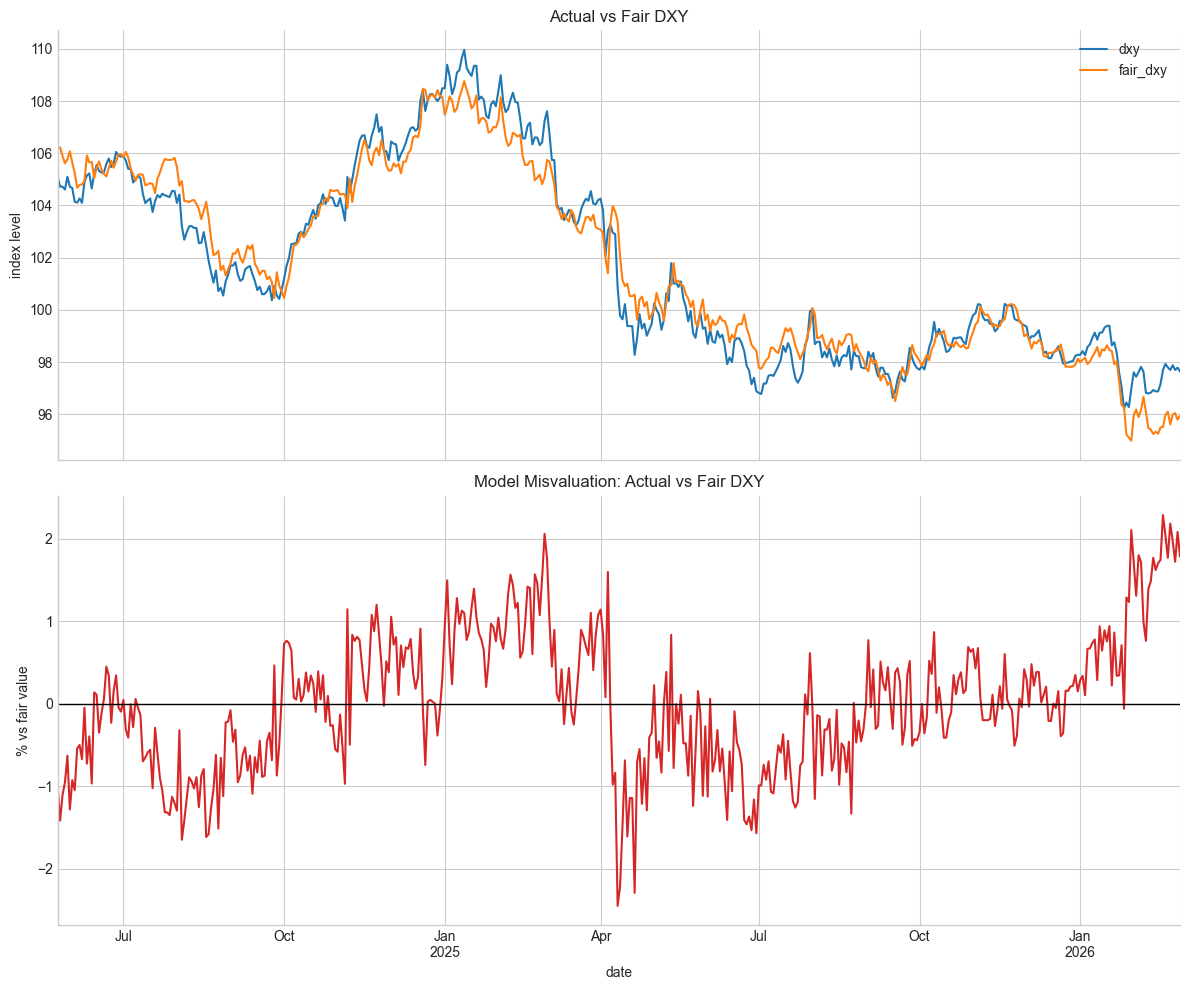

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

valuation_df[["dxy", "fair_dxy"]].plot(ax=axes[0], title="Actual vs Fair DXY")
axes[0].set_ylabel("index level")

valuation_df["misvaluation_pct"].plot(ax=axes[1], color="tab:red", title="Model Misvaluation: Actual vs Fair DXY")
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set_ylabel("% vs fair value")

plt.tight_layout()
plt.show()


In [6]:
valuation_df.to_csv(VALUATION_CSV)
print("saved valuation panel to", VALUATION_CSV)
valuation_df[["dxy", "fair_dxy", "misvaluation_pct"]].tail()


saved valuation panel to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-27_global_macro_trading_gliner/02_dxy_valuation_panel.csv


                  dxy   fair_dxy  misvaluation_pct
date                                              
2026-02-23  97.699997  95.613361          2.182368
2026-02-24  97.879997  95.987566          1.971538
2026-02-25  97.699997  96.047688          1.720301
2026-02-26  97.790001  95.796721          2.080739
2026-02-27  97.646004  95.936906          1.781481